# Occurrence-Dynamics Alternatives: QQ and ACF Mosaics

## Objective

`run_pi_dynamics_alternatives.py` already fit four alternative
specifications for the occurrence probability $\pi_{t|t-1}$ at each of
the six completed locations (see `pi_dynamics/ar_logistic_custom_lags.py`,
`pi_dynamics/phi_linked.py`, and `generate_pi_dynamics_report.py`, which
already reports on all four). This notebook builds **four mosaic
figures** -- one QQ-plot mosaic and one 400-lag ACF mosaic, for each of
two headline alternatives:

- **Phi-linked** (`phi_linked`): $\eta_t = \lambda_0 + \lambda_1\,\varphi_{t|t-1}$
  -- the occurrence logit driven directly by the GAS scale state.
- **Autoregressive** (`existing_ar_seasonal`): $\eta_t = \omega_0 + \rho\,\eta_{t-1}
  + \sum_{l\in\{1,365,366\}}\omega_l\,y_{t-l}$ -- the pre-existing
  AR-logistic occurrence dynamics used everywhere else in the Stage 1-4
  pipeline (see `docs/MODELS.md` Sec 3), included here as the natural
  baseline to contrast against the phi-linked proposal.

(Two further ablations exist in the underlying experiment --
`short_lags_ar`, `short_lags_noar` -- but per the user's request only
these two headline alternatives get their own dissertation figures here.
See the Configuration cell below to add a third if ever needed.)

Each mosaic is a fixed 2-column grid, one panel per location. Every
number plotted was already computed and saved by
`run_pi_dynamics_alternatives.py` at fit time (`paths.npz`'s `"qr"`
array -- the in-sample quantile residual $r_t = \Phi^{-1}(F_t(y_t))$ for
this Bernoulli occurrence model). **No model is re-fit or re-estimated
here** (`docs/EXECUTION.md` Sec 22: "Reports should never call
optimization") -- this notebook only loads saved artifacts and plots them.

Outputs are written to `reports/pi_dynamics_alternatives/mosaics/`.


## Mathematical Background

### Quantile residuals for a Bernoulli occurrence model

Let $z_t = \mathbb{1}(y_t > 0)$ (rain / no-rain) and $\pi_{t|t-1}$ the
model's one-step-ahead occurrence probability. The predictive CDF of
$z_t$ is a two-point distribution, so its PIT is randomised exactly as
for the zero mass in the full ZA-GAS model (`diagnostics/occurrence_pit.py`):
for $z_t=0$, $u_t \sim \text{Uniform}(0, 1-\pi_{t|t-1})$; for $z_t=1$,
$u_t \sim \text{Uniform}(1-\pi_{t|t-1}, 1)$. The quantile residual is then
$r_t = \Phi^{-1}(u_t)$. Under a correctly specified occurrence model,
$r_t \sim \text{iid } N(0,1)$ -- so the same QQ-plot and ACF diagnostics
used throughout this repository's other mosaics apply unchanged.

### Normal QQ plot

Sorted $\{r_t\}$ against theoretical $N(0,1)$ quantiles (Blom-type
plotting positions). Points should fall on the 45-degree reference line;
departures at the extremes indicate poor tail calibration of the
occurrence probability (rare here, since occurrence is a bounded $[0,1]$
probability rather than a heavy-tailed magnitude, but systematic
curvature still indicates miscalibration).

### Residual ACF and its confidence band

Same construction as every other ACF panel in this repository
(`diagnostics/plots.py` module docstring): the sample autocorrelation
$\hat\rho_k$ of $\{r_t\}$ at lag $k=1,\dots,400$ is asymptotically
$N(0,1/n)$ under the null of no autocorrelation, giving the shaded
$\pm 2/\sqrt n$ band shown in every panel. Autocorrelation surviving this
band (especially near lag $\approx 365$) indicates the occurrence
dynamics have not fully absorbed the seasonal rainfall cycle.


In [1]:
# =============================================================================
# Imports and project-root path setup
# =============================================================================
# This notebook ORCHESTRATES only -- per docs/EXECUTION.md Sec 23
# ("Notebooks should orchestrate experiments ... They should not contain
# model implementations"), every non-trivial computation (loading saved
# quantile residuals, mosaic figure construction) lives in reusable
# modules:
#     diagnostics/pi_dynamics_alt_mosaics.py  -- which artifacts to load
#     diagnostics/plots.py                    -- what the mosaics look like
# This notebook just calls them in the right order and saves the results.

from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless rendering -- figures are displayed below
                        # via explicit fig.savefig() + IPython Image, not
                        # matplotlib's interactive/inline backend, so this
                        # notebook renders identically whether run inside
                        # Jupyter or from the command line (nbconvert).
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Project root = the directory this notebook lives in.
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from diagnostics.multilocation_mosaics import LOCATIONS
from diagnostics.pi_dynamics_alt_mosaics import (
    load_qr_by_location, PHI_LINKED_VARIANT_KEY, AUTOREGRESSIVE_VARIANT_KEY,
)
from diagnostics.plots import qq_location_mosaic, acf_location_mosaic
from data.station_loader import STATION_REGISTRY, mosaic_name

print("Locations:", LOCATIONS)
print("Phi-linked variant key:   ", PHI_LINKED_VARIANT_KEY)
print("Autoregressive variant key:", AUTOREGRESSIVE_VARIANT_KEY)


Locations: ['BELO HORIZONTE', 'CRUZEIRO DO SUL (ACRE)', 'DARWIN AIRPORT', 'GARANHUNS (PERNAMBUCO)', 'MANAUS', 'SALVADOR']
Phi-linked variant key:    phi_linked
Autoregressive variant key: existing_ar_seasonal


## Configuration -- EDIT HERE for titles, filenames, or which variant is shown

**This is the one cell to change to rename an output file, reword a
title, or swap in a different pi-dynamics variant.** Nothing below this
cell needs to change for any of that -- the generation loop just reads
this dictionary.


In [2]:
# =============================================================================
# Configuration
# =============================================================================
# One entry per headline alternative shown in this notebook. Each entry's
# "variant_key" must be one of diagnostics.pi_dynamics_alt_mosaics.
# VARIANT_ORDER = ["existing_ar_seasonal", "short_lags_ar", "short_lags_noar",
# "phi_linked"] -- see that module's docstring for what each one is.
#
# To rename a figure file: edit "qq_filename" / "acf_filename" below.
# To reword a title: edit "qq_title" / "acf_title" below (LaTeX allowed,
# matplotlib mathtext -- e.g. "$\\pi_{t|t-1}$").
# To add a third alternative (e.g. "short_lags_ar"): copy one of the two
# dict entries below, give it a new key, and change "variant_key".
ALTERNATIVES = {
    "phi_linked": {
        "variant_key": PHI_LINKED_VARIANT_KEY,
        "qq_title":  r"in-sample $\pi_{t|t-1}$ dependent on $\varphi$, theoretical "
                     r"N(0,1) quantiles versus empirical quantile residuals",
        "acf_title": r"in-sample $\pi_{t|t-1}$ dependent on $\varphi$, ACF with 400 lags",
        "qq_filename":  "phi_linked_qq_mosaic",
        "acf_filename": "phi_linked_acf400_mosaic",
    },
    "autoregressive": {
        "variant_key": AUTOREGRESSIVE_VARIANT_KEY,
        "qq_title":  r"in-sample $\pi_{t|t-1}$ autoregressive, theoretical "
                     r"N(0,1) quantiles versus empirical quantile residuals",
        "acf_title": r"in-sample $\pi_{t|t-1}$ autoregressive, ACF with 400 lags",
        "qq_filename":  "autoregressive_qq_mosaic",
        "acf_filename": "autoregressive_acf400_mosaic",
    },
}

# Column order for both mosaics -- location *display* names, in the same
# order as diagnostics/multilocation_mosaics.py's LOCATIONS (and therefore
# the same order used by every other mosaic notebook in this repo), filled
# into the fixed 2-column grid row-major.
LOCATION_DISPLAY_NAMES = [STATION_REGISTRY[s]["display"] for s in LOCATIONS]

# Per-location panel-title overrides -- same convention as
# multilocation_diagnostic_mosaics.ipynb / pi_monthly_seasonality_mosaics.ipynb:
#   LOCATION_NAMES     -- text actually drawn (only Darwin Airport differs
#                         from its own "display" name; see mosaic_name()).
#   LOCATION_COUNTRIES -- "(Country)" subtitle, from STATION_REGISTRY.
LOCATION_NAMES     = {STATION_REGISTRY[s]["display"]: mosaic_name(s) for s in LOCATIONS}
LOCATION_COUNTRIES = {STATION_REGISTRY[s]["display"]: f"({STATION_REGISTRY[s]['country']})" for s in LOCATIONS}

# Output location. reports/pi_dynamics_alternatives/ already holds
# generate_pi_dynamics_report.py's own report.tex/figures/tables; these
# mosaics live in their own clearly separated subfolder so nothing here
# ever collides with or overwrites that report's own artifacts.
REPORT_DIR = ROOT / "reports" / "pi_dynamics_alternatives"
MOSAICS_DIR = REPORT_DIR / "mosaics"
MOSAICS_DIR.mkdir(parents=True, exist_ok=True)

ACF_N_LAGS = 400  # per docs/REPORTING.md Sec 13 ("Residual ACF should use 400 lags")
DPI = 150         # matches generate_report_extended.py's per-model figure resolution

print("Mosaics will be written to:", MOSAICS_DIR)
for alt_key, cfg in ALTERNATIVES.items():
    print(f"  {alt_key}: variant_key={cfg['variant_key']!r}, "
          f"files={cfg['qq_filename']}.png/pdf, {cfg['acf_filename']}.png/pdf")


Mosaics will be written to: C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\reports\pi_dynamics_alternatives\mosaics
  phi_linked: variant_key='phi_linked', files=phi_linked_qq_mosaic.png/pdf, phi_linked_acf400_mosaic.png/pdf
  autoregressive: variant_key='existing_ar_seasonal', files=autoregressive_qq_mosaic.png/pdf, autoregressive_acf400_mosaic.png/pdf


## Figure design settings -- EDIT HERE for font size / readability

**This is the one cell to change if the text in the mosaics looks too
small (or too big) once placed in the LaTeX dissertation.** No other cell
in this notebook needs to change for that -- same print-size calibration
used by every other mosaic notebook in this repo
(`multilocation_diagnostic_mosaics.ipynb`, `pi_monthly_seasonality_mosaics.ipynb`):
`BASE_PRINT_PT` fixes the point size that should appear **on the printed
page** (calibrated to this dissertation's 12pt Latin Modern Roman body
text), and `TARGET_PRINT_WIDTH_IN` is the width (inches) the figure will
actually be placed at in the document.

These are compact 2-column figures (like the monthly $\pi_t$ mosaics),
meant for a normal **portrait** page at `\textwidth` -- hence the smaller
`6.3`in default below, rather than the `9.5`in used for the wide Stage
1-4 stage/branch grids.


In [3]:
# =============================================================================
# FIGURE DESIGN SETTINGS -- font size / print-scale calibration
# =============================================================================
# Passed as target_print_width_in= / base_print_pt= into every
# qq_location_mosaic() / acf_location_mosaic() call below --
# diagnostics/plots.py's own TARGET_PRINT_WIDTH_IN / BASE_PRINT_PT are only
# the fallback defaults used if you call those functions directly without
# overriding them, so editing the copies here is enough.

TARGET_PRINT_WIDTH_IN = 6.3  # normal portrait \textwidth figure

BASE_PRINT_PT = {
    "suptitle":   17.0,  # figure title (these titles run long, so slightly
                         # smaller than the 18-20pt used elsewhere to avoid
                         # wrapping awkwardly across the page width)
    "header":     14.0,  # per-panel titles (location names)
    "axis_label": 12.0,  # x/y axis labels -- matches the dissertation body text
    "tick":       10.0,  # tick labels
    "legend":     11.0,  # shared legend text, placed above the panels
    "annotation": 9.0,   # in-panel "n=..." text and "not run" placeholder text
}

print(f"Target print width: {TARGET_PRINT_WIDTH_IN} in")
print("Base print point sizes:", BASE_PRINT_PT)


Target print width: 6.3 in
Base print point sizes: {'suptitle': 17.0, 'header': 14.0, 'axis_label': 12.0, 'tick': 10.0, 'legend': 11.0, 'annotation': 9.0}


In [4]:
# =============================================================================
# Saving helper
# =============================================================================

def save_mosaic(fig: "plt.Figure", stem: str) -> Path:
    # Saves a mosaic Figure as both PNG (quick viewing) and PDF (vector,
    # for LaTeX embedding per docs/REPORTING.md Sec 26.12: "figures as PDF
    # and PNG"), closes it to free memory, then displays the PNG inline.
    # bbox_inches="tight" expands the saved bounding box to include the
    # shared legend/suptitle placed in the figure's top margin (see
    # diagnostics/plots.py's _fig_legend_above_panels) -- without it, a
    # long suptitle can be clipped at the nominal figure edges.
    png_path = MOSAICS_DIR / f"{stem}.png"
    pdf_path = MOSAICS_DIR / f"{stem}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(png_path)))
    return png_path


## Generate all four mosaics

Loops over `ALTERNATIVES` (Configuration cell above) -- nothing here
needs to change to rename a file or reword a title; edit that dictionary
instead.



phi_linked  (variant_key='phi_linked')


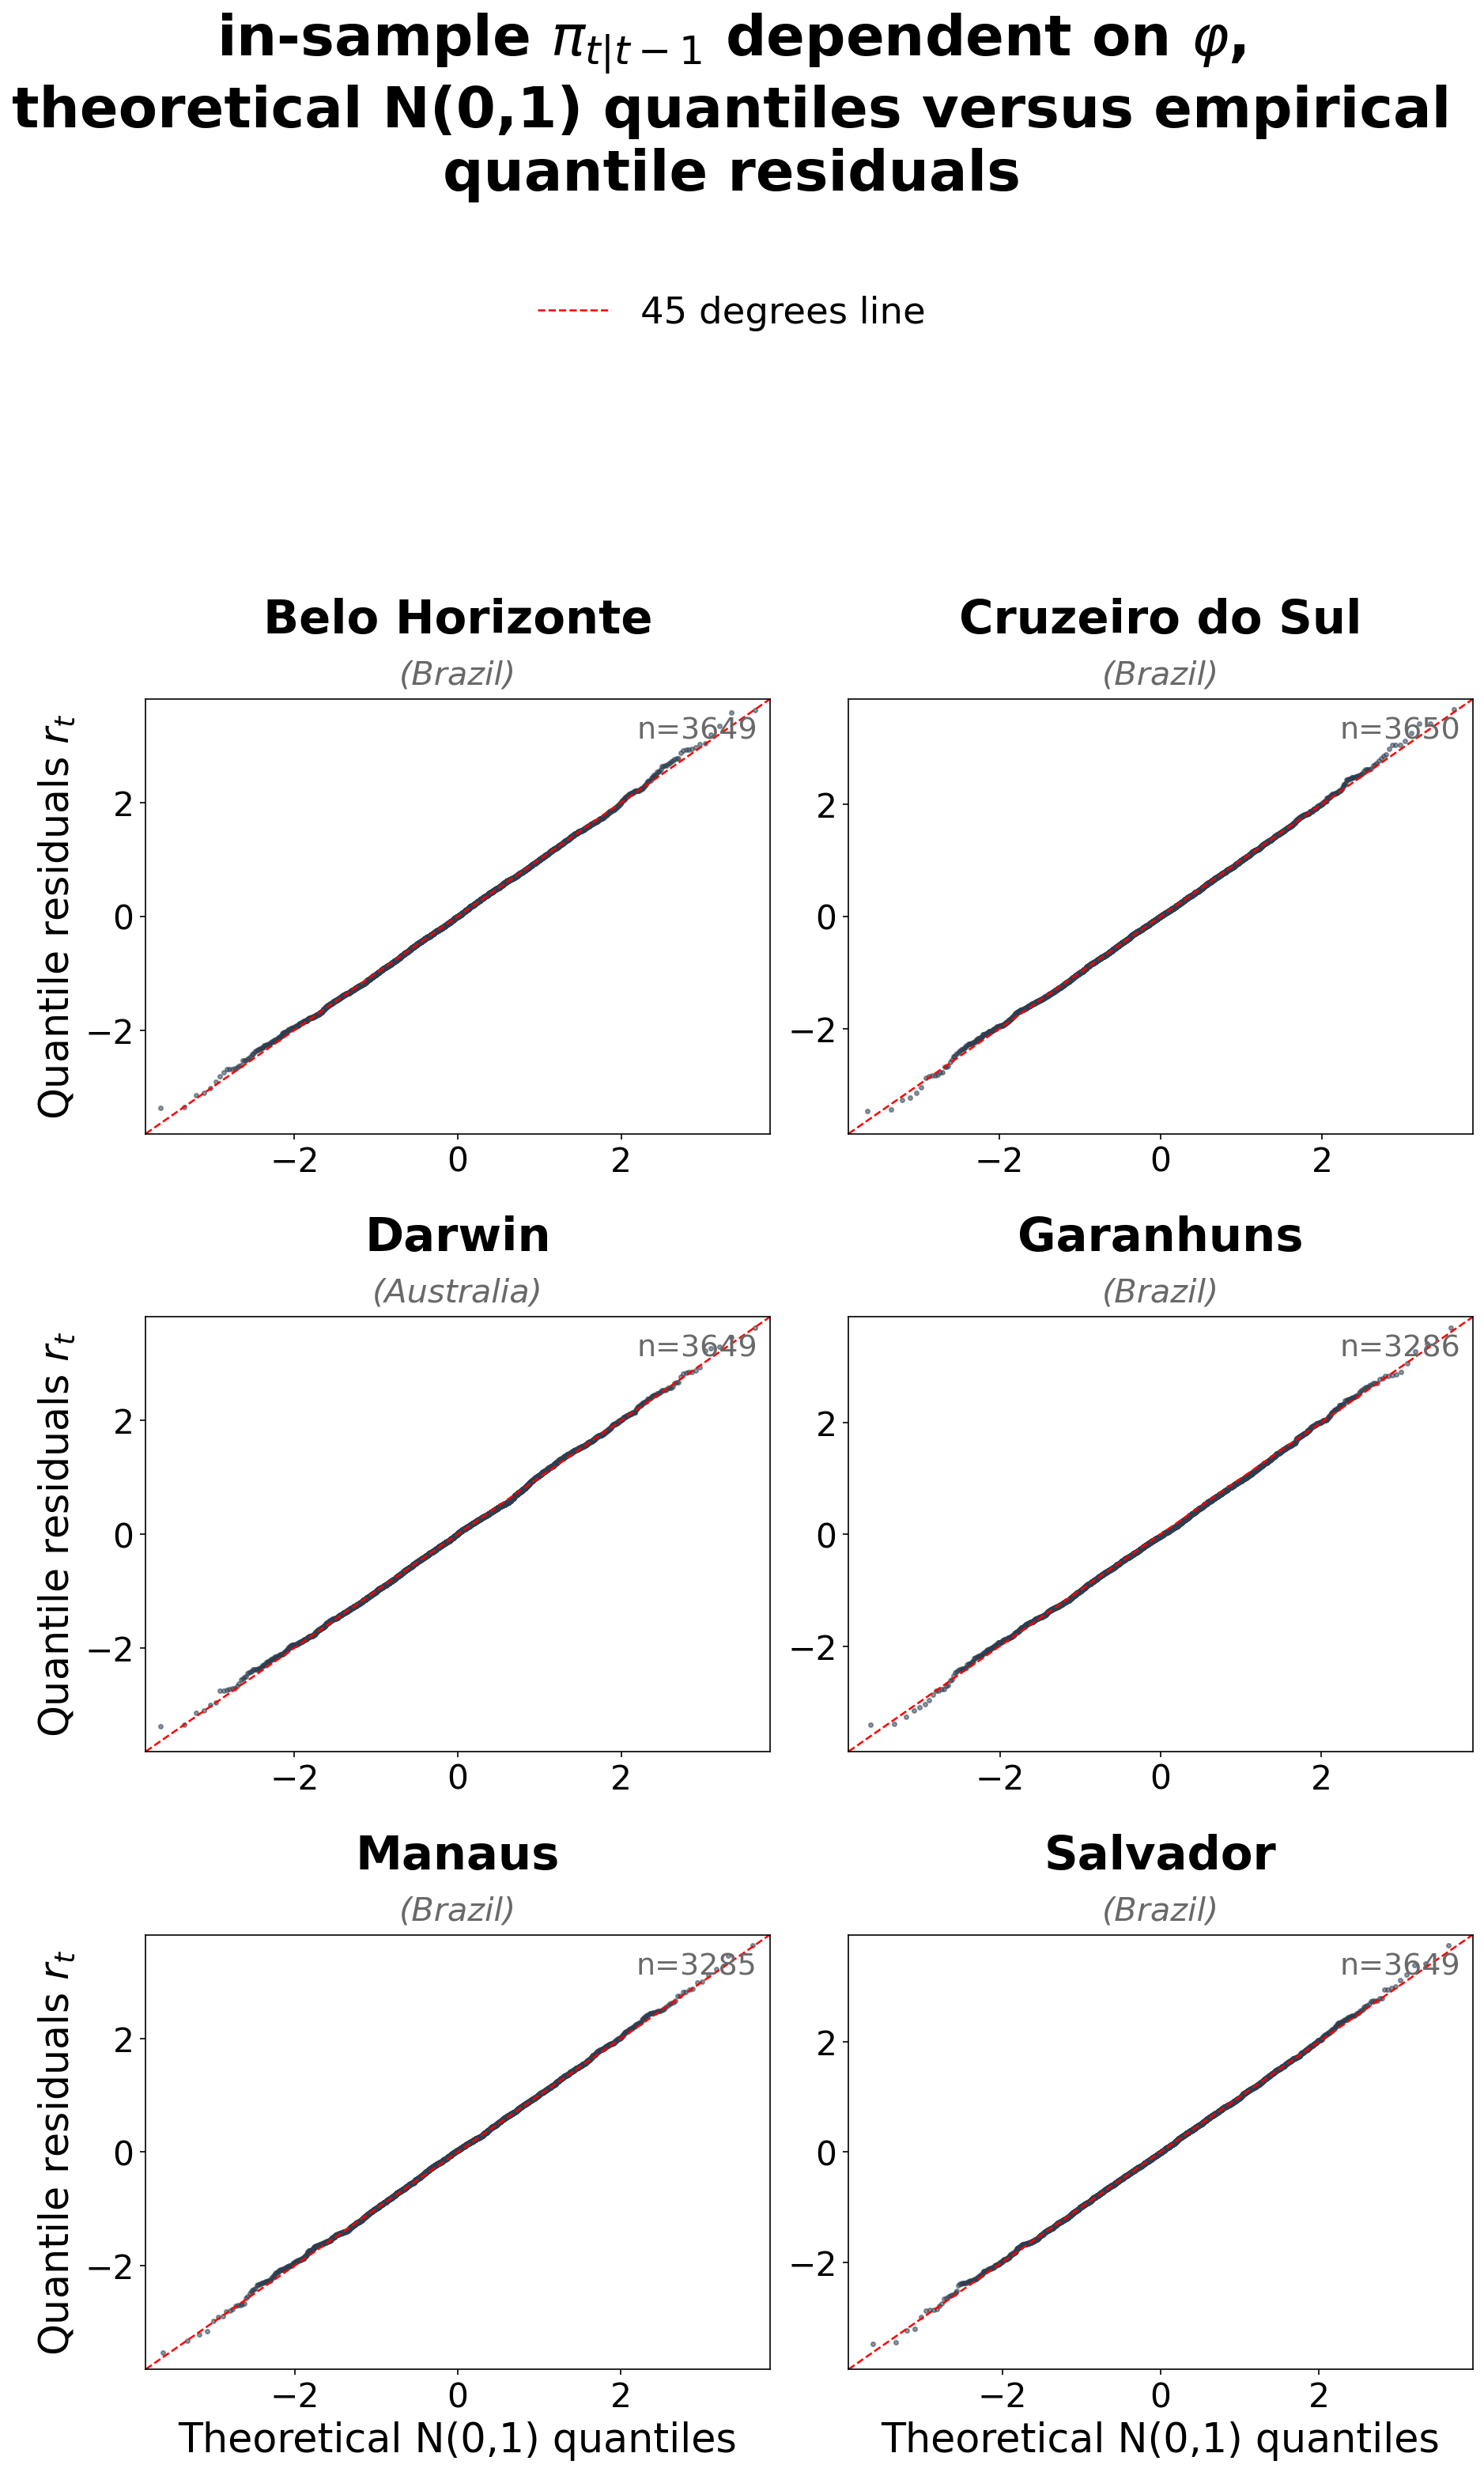

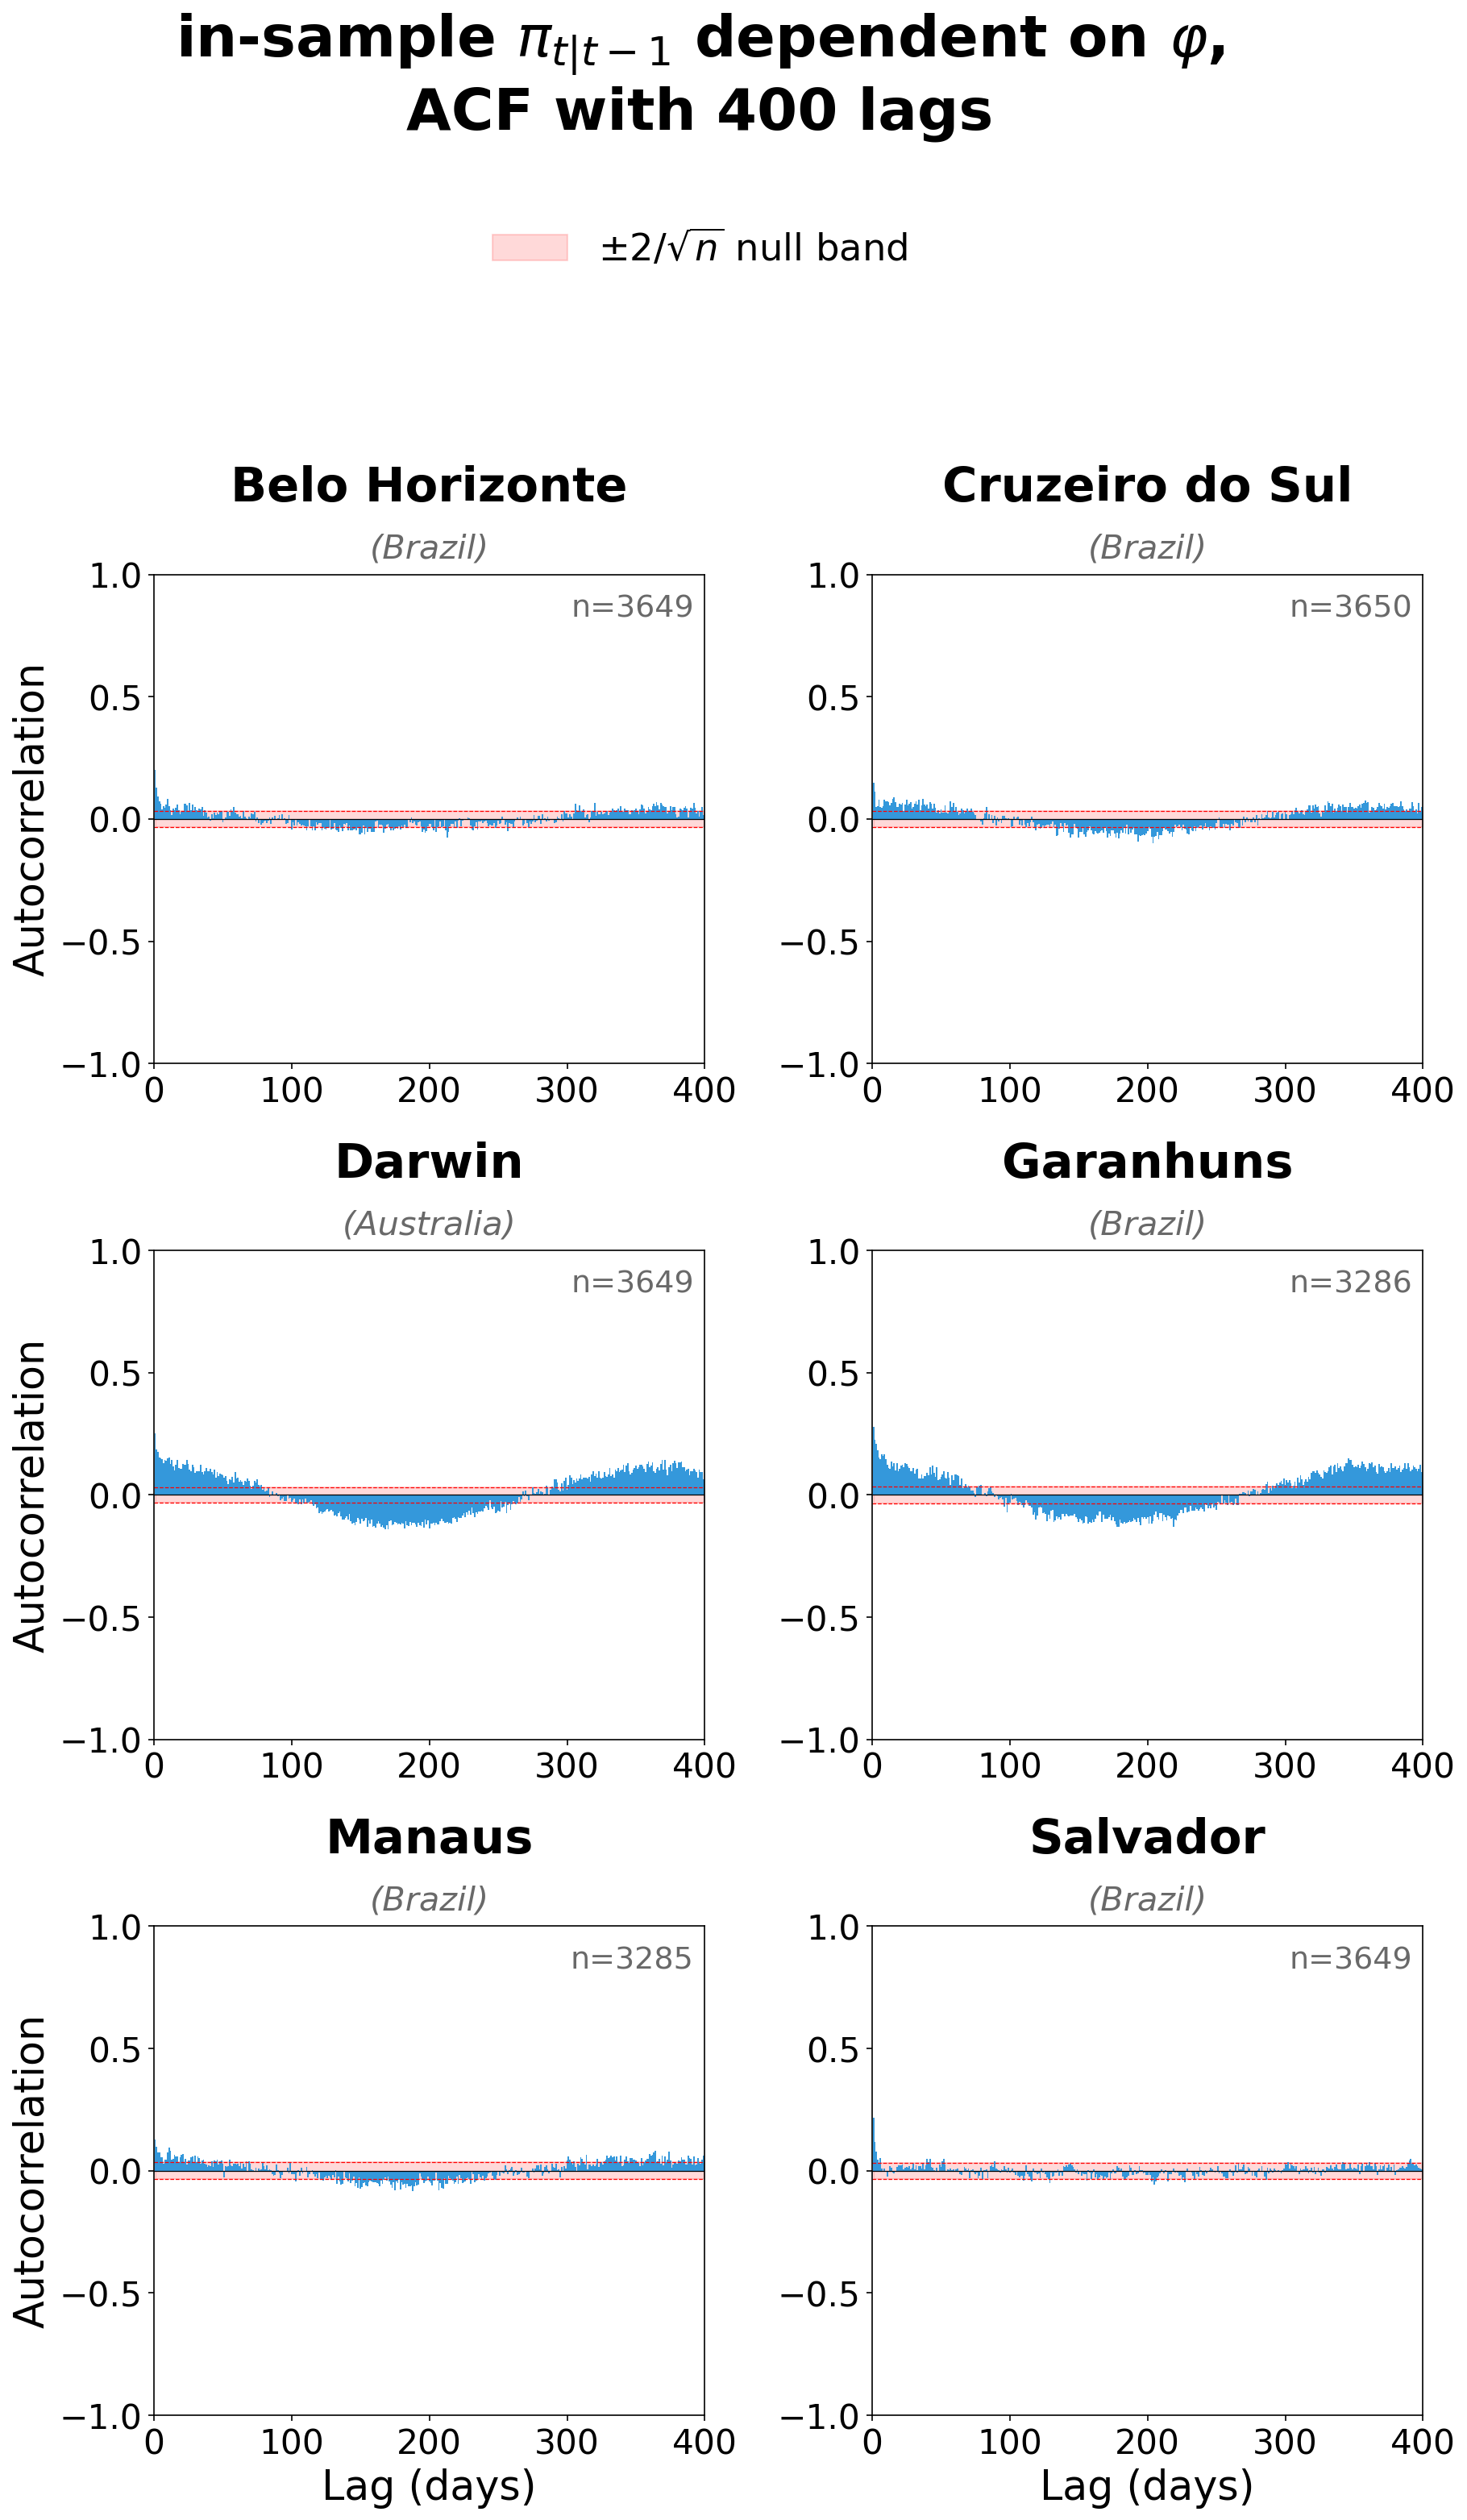


autoregressive  (variant_key='existing_ar_seasonal')


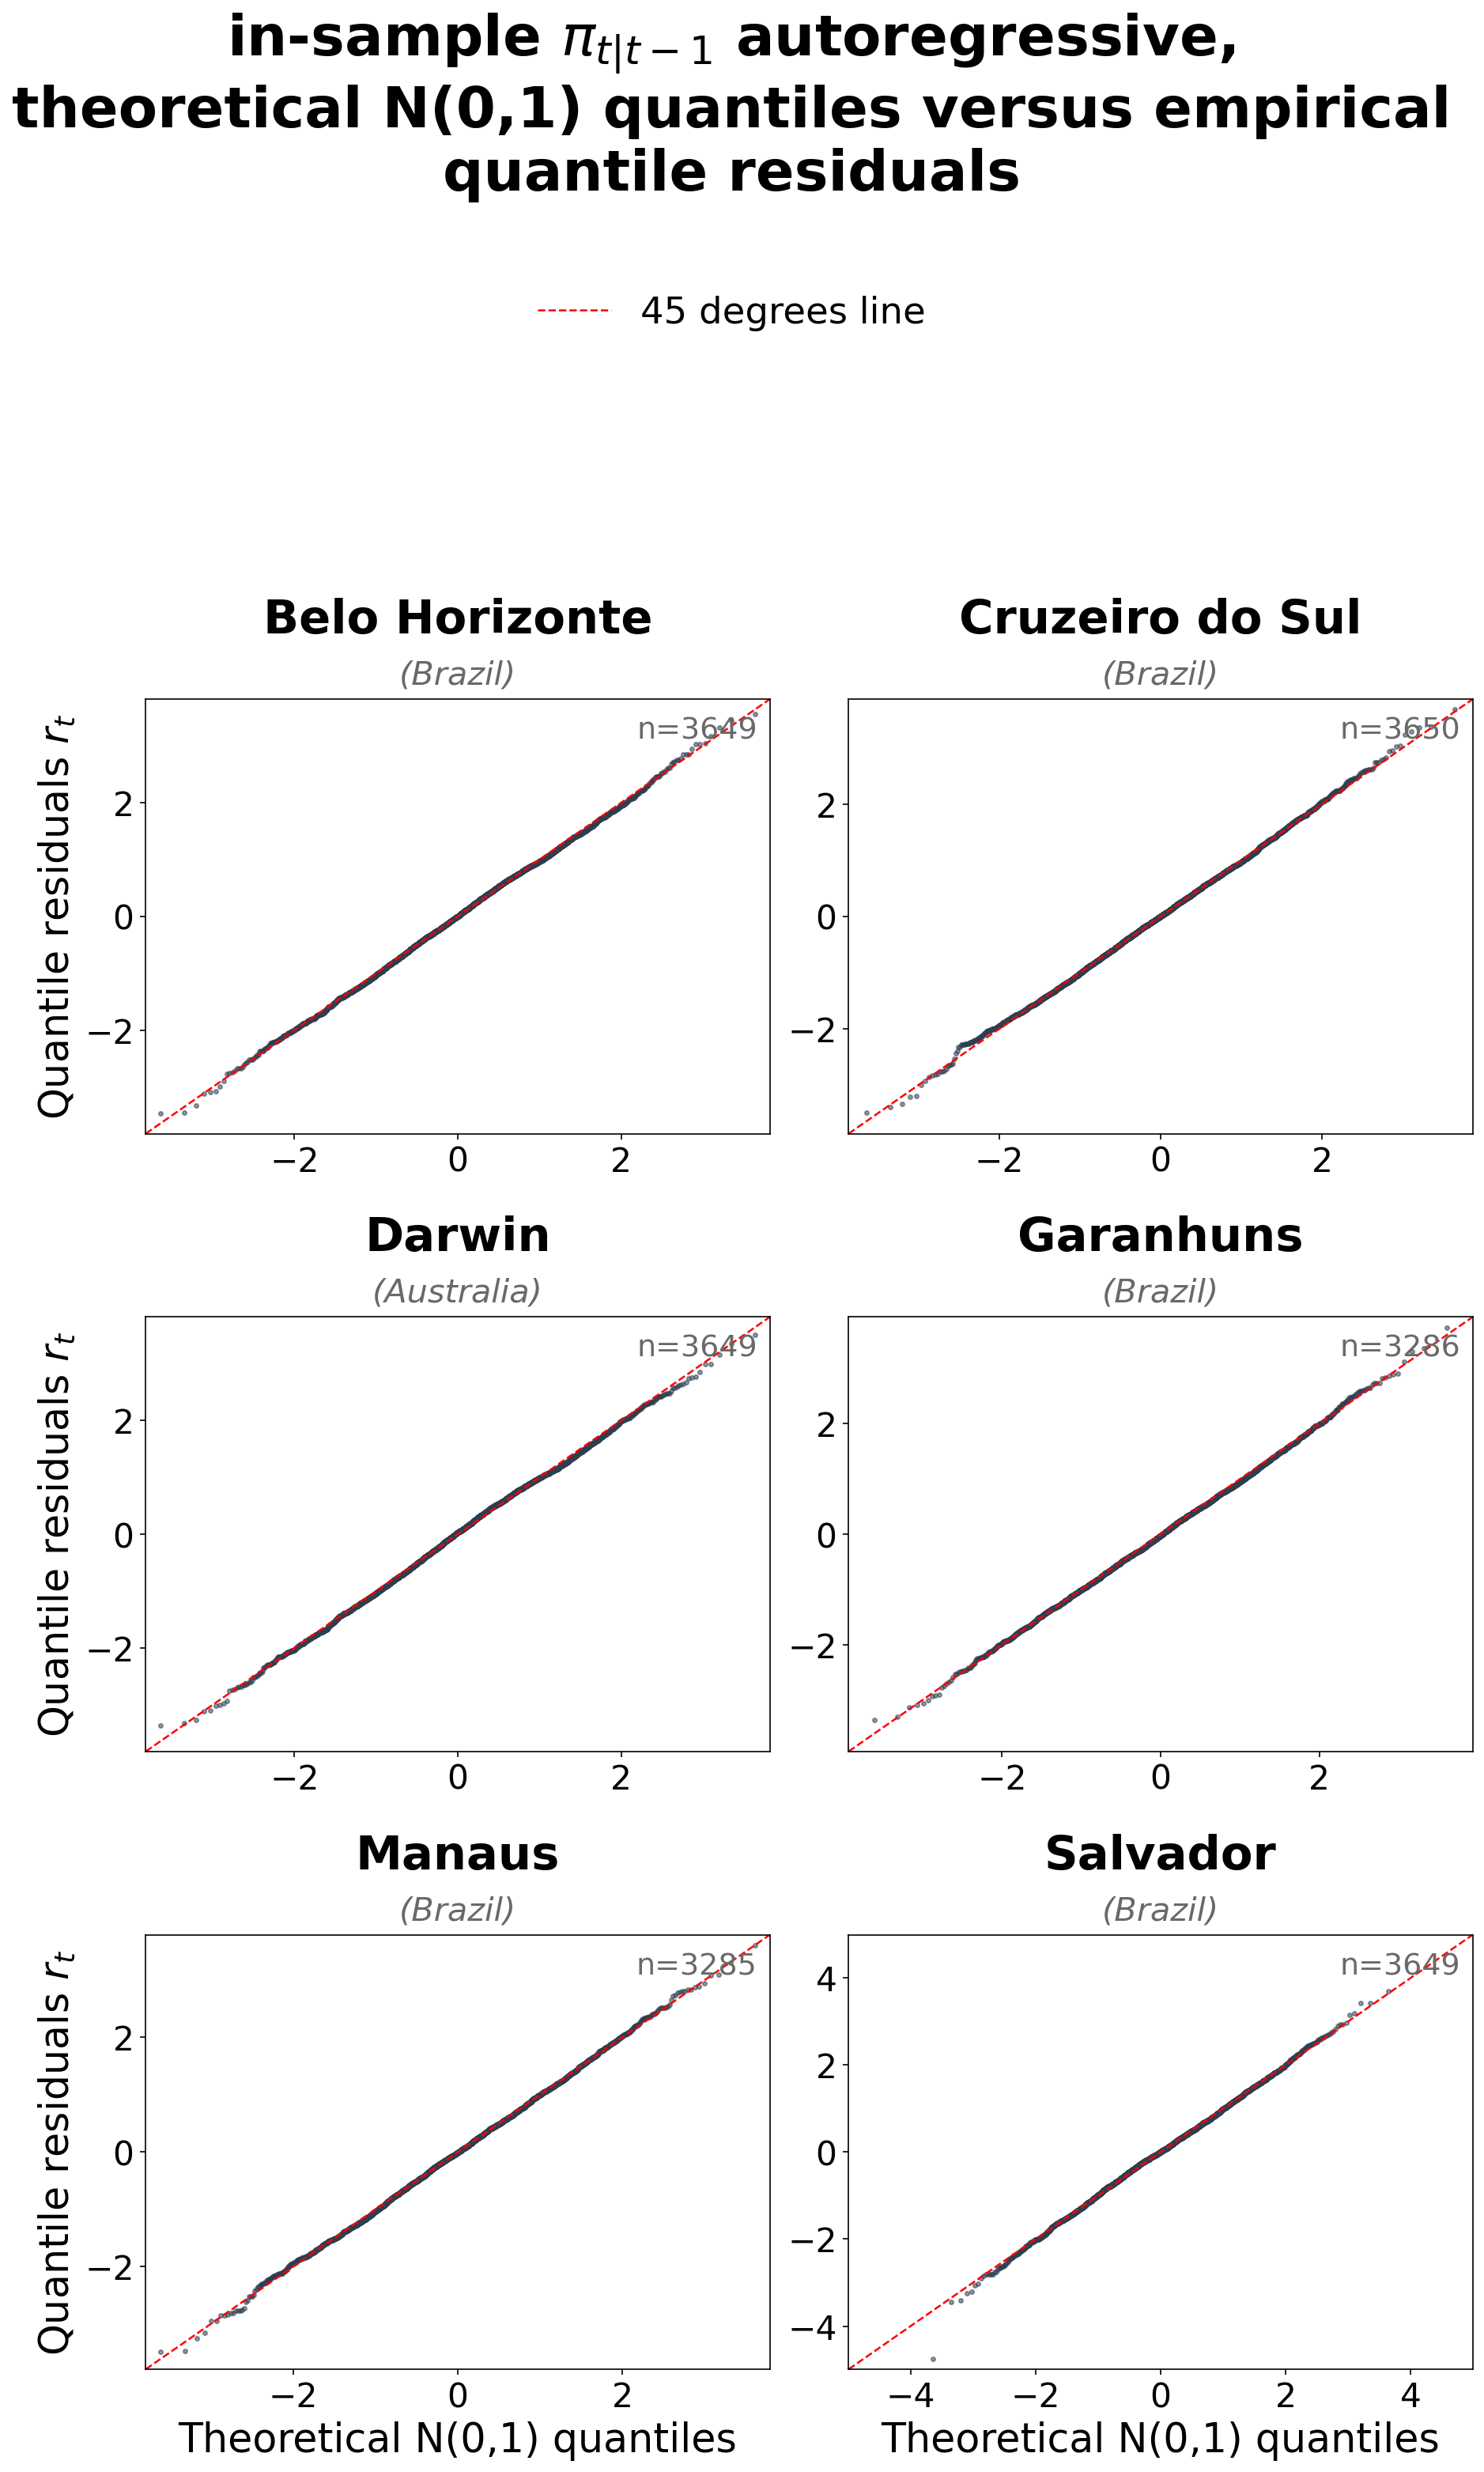

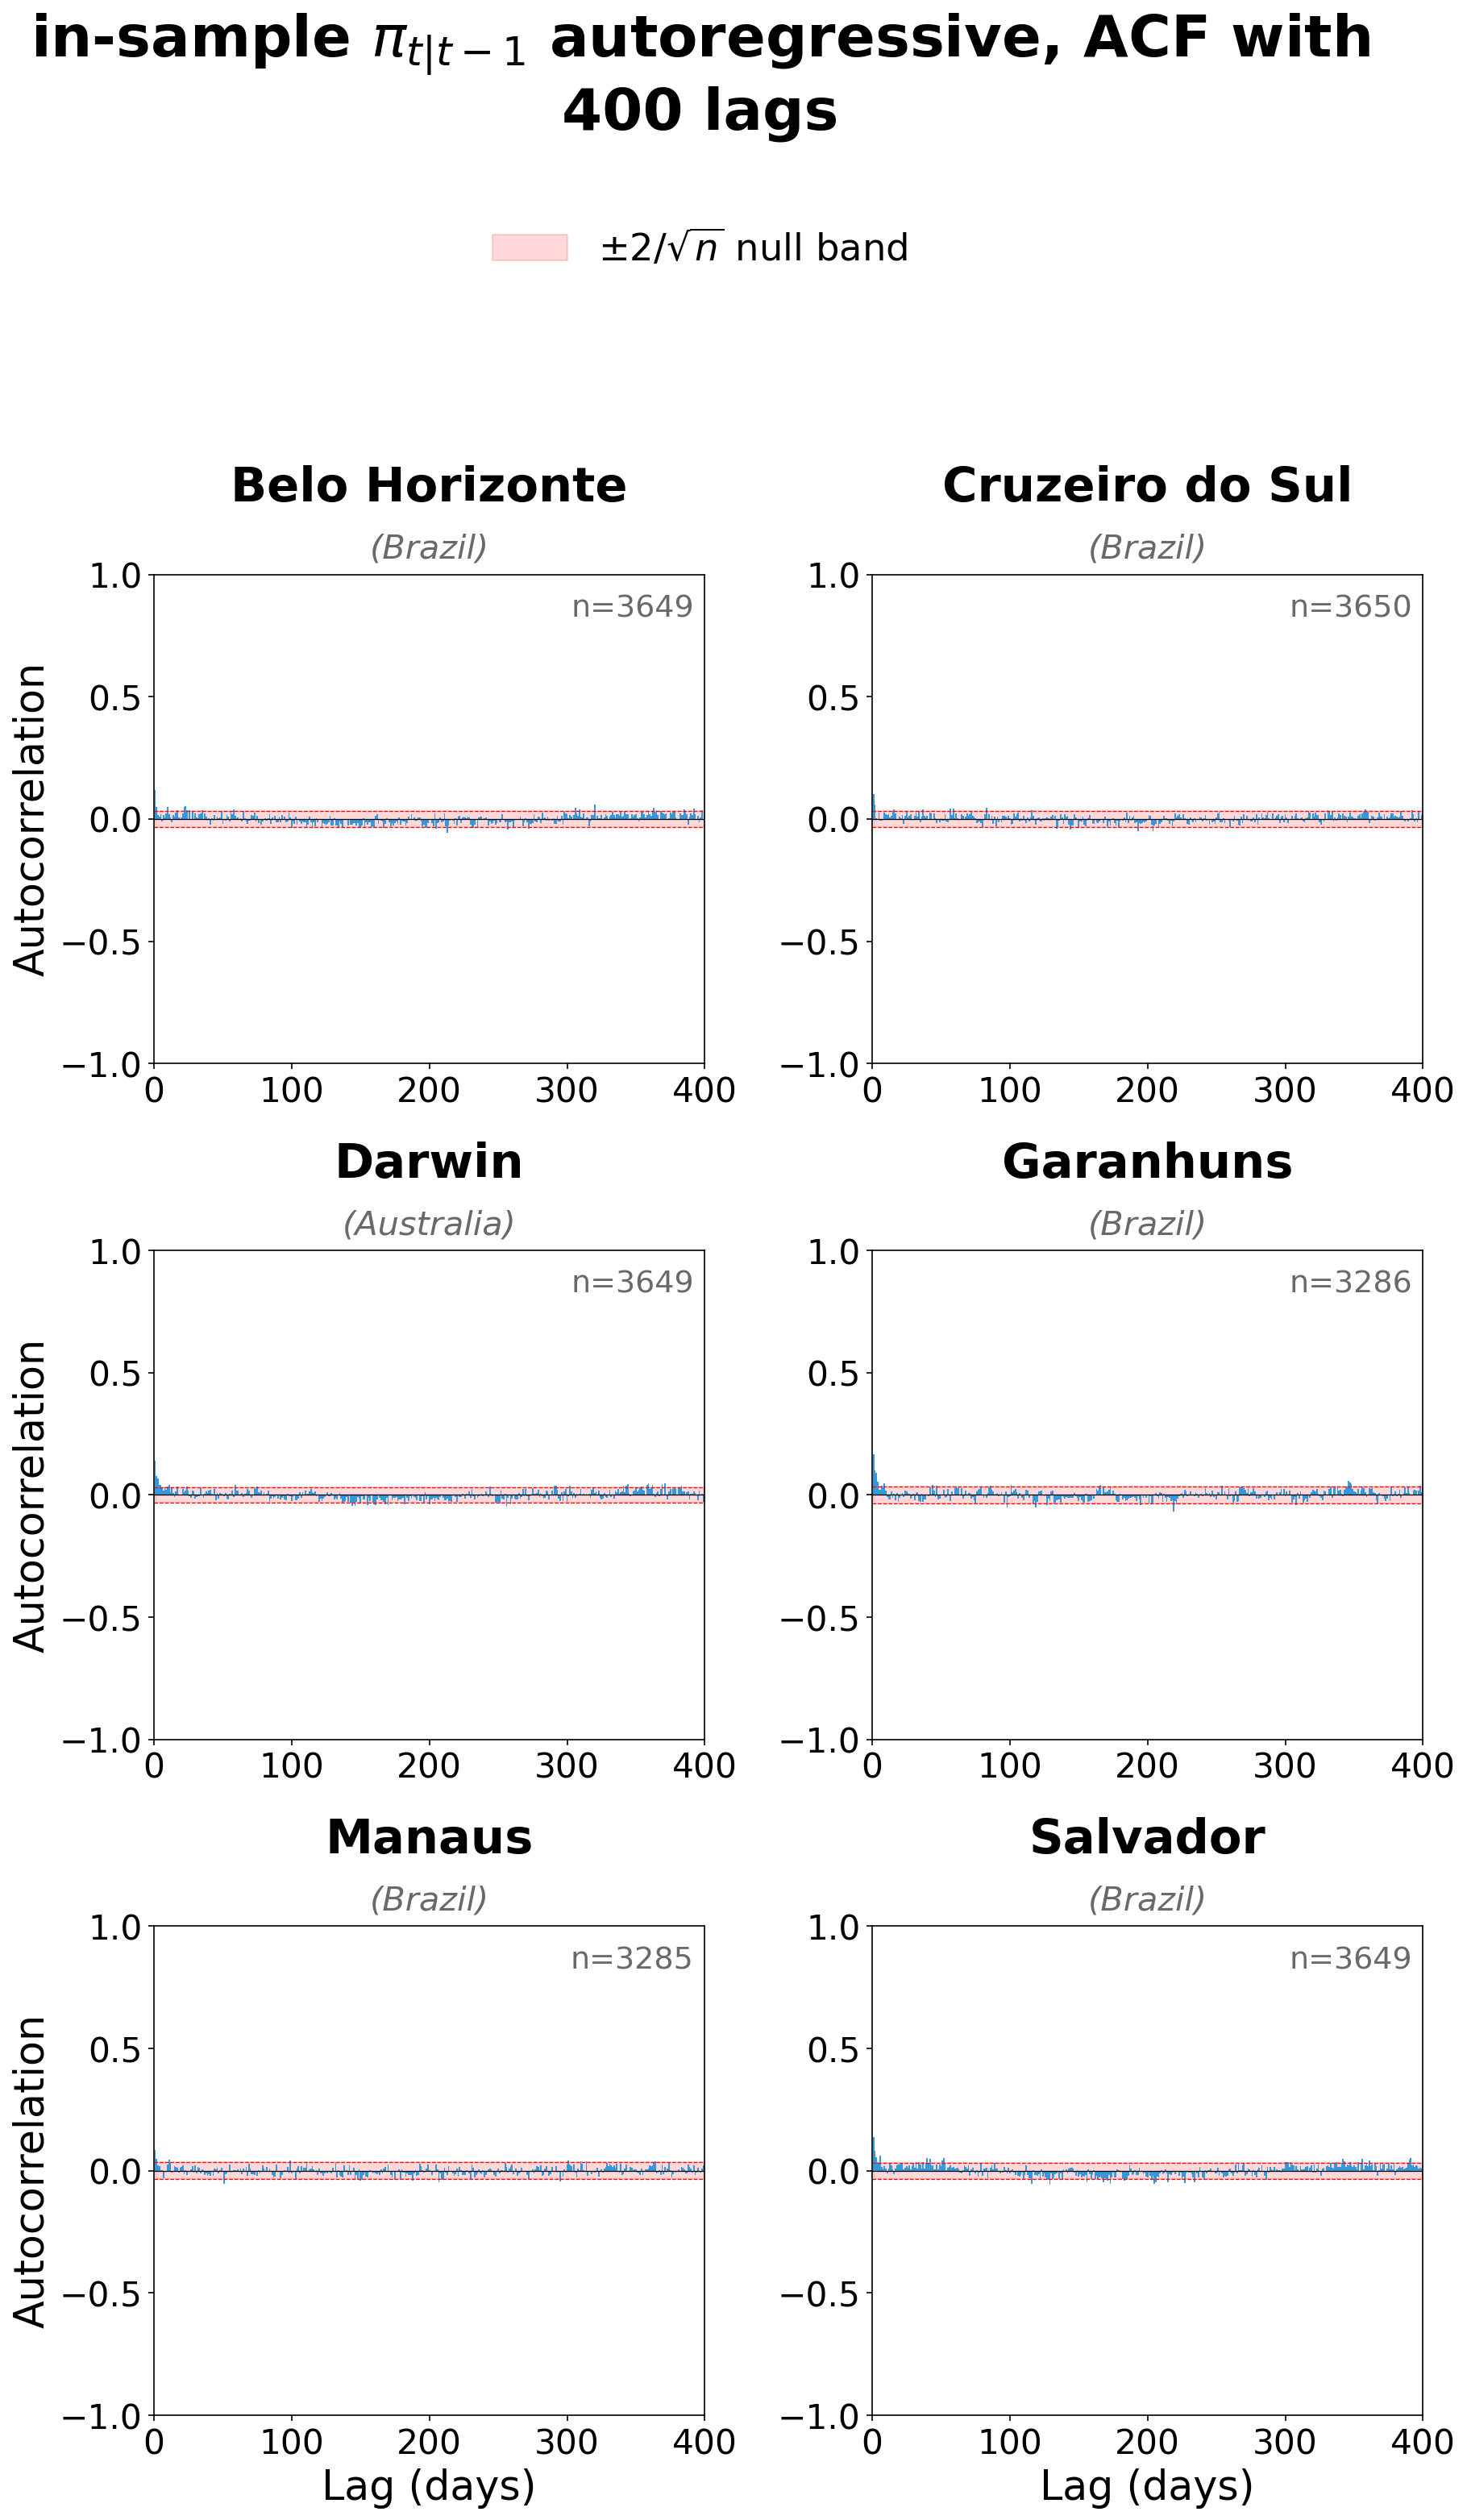


Generated 4 mosaic files in C:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\FurtherTopics\reports\pi_dynamics_alternatives\mosaics


In [5]:
generated_files = []
qr_cache = {}  # variant_key -> {location: qr array or None}, loaded once each

for alt_key, cfg in ALTERNATIVES.items():
    variant_key = cfg["variant_key"]
    print(f"\n{'=' * 70}\n{alt_key}  (variant_key={variant_key!r})\n{'=' * 70}")

    if variant_key not in qr_cache:
        qr_cache[variant_key] = load_qr_by_location(variant_key)
    qr_by_location = qr_cache[variant_key]

    fig_qq = qq_location_mosaic(
        qr_by_location, LOCATION_DISPLAY_NAMES, suptitle=cfg["qq_title"],
        target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
        location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
    )
    generated_files.append(save_mosaic(fig_qq, cfg["qq_filename"]))

    fig_acf = acf_location_mosaic(
        qr_by_location, LOCATION_DISPLAY_NAMES, suptitle=cfg["acf_title"],
        n_lags=ACF_N_LAGS,
        target_print_width_in=TARGET_PRINT_WIDTH_IN, base_print_pt=BASE_PRINT_PT,
        location_names=LOCATION_NAMES, location_countries=LOCATION_COUNTRIES,
    )
    generated_files.append(save_mosaic(fig_acf, cfg["acf_filename"]))

print(f"\nGenerated {len(generated_files)} mosaic files in {MOSAICS_DIR}")


In [6]:
# =============================================================================
# Save a file index for the generated mosaics
# =============================================================================
index_df = pd.DataFrame({"file": [p.name for p in generated_files]})
index_df.to_csv(MOSAICS_DIR / "mosaic_file_index.csv", index=False)
index_df


,file
0,phi_linked_qq_mosaic.png
1,phi_linked_acf400_mosaic.png
2,autoregressive_qq_mosaic.png
3,autoregressive_acf400_mosaic.png


## How to change the figure design

**Font size / readability in the PDF:** edit the "Figure design settings"
cell above (`TARGET_PRINT_WIDTH_IN`, `BASE_PRINT_PT`).

**Titles, output filenames, or which variant is shown:** edit the
`ALTERNATIVES` dictionary in the Configuration cell -- every title and
filename in this notebook comes from that one dictionary, and the
generation loop is otherwise unchanged. No other cell needs touching for
any of that.

**Why the QQ and ACF mosaics are always exactly the same size:** both
`qq_location_mosaic` and `acf_location_mosaic` (`diagnostics/plots.py`)
read their figure size from one shared module-level constant,
`LOCATION_QQACF_PANEL_SIZE_IN = (6.4, 7.0)` (width per column, height per
row, in inches) -- neither function has its own separate size number.
Change that one constant (just above `qq_location_mosaic`'s definition)
to resize both mosaics at once; they cannot drift apart because there is
nowhere else a size is set. If you ever shrink it, re-check for the
native y-axis label bleeding into the row above/below (a real failure
mode here -- see that constant's own comment) before trusting the render.

**Why a long title wraps onto extra lines instead of overflowing:**
`diagnostics/plots.py`'s `_wrap_title_to_width` estimates how many
characters fit in the figure's own physical width at the title's
calibrated font size, and wraps the `suptitle` text onto that many extra
lines with Python's `textwrap`. `_place_wrapped_title_and_legend` then
figures out how much vertical room that many lines need and positions
the shared legend and the plot area below it accordingly. Both
`qq_location_mosaic` and `acf_location_mosaic` call this same pair of
helpers (rather than each computing its own wrap width), which is what
keeps the wrap threshold identical for every chart that uses them,
whatever that chart's own title text happens to be.

**Row labels (location name + country):** `LOCATION_NAMES` /
`LOCATION_COUNTRIES`, built in the Configuration cell from
`data/station_loader.py`'s `mosaic_name()` and the `STATION_REGISTRY`
`"country"` field -- edit the registry there to rename a location or
change its country, not this notebook.

**Colors, marker size, line widths, panel layout:** these mosaics reuse
`diagnostics/plots.py`'s `qq_location_mosaic` / `acf_location_mosaic`,
which in turn reuse the same `_draw_qq_panel` / `_draw_acf_panel`
single-panel drawers as every other QQ/ACF mosaic in this repository --
edit those two functions to restyle every QQ or ACF panel in the whole
project at once (they are not duplicated per mosaic).

**Which pi-dynamics variant counts as "autoregressive":**
`diagnostics/pi_dynamics_alt_mosaics.py`'s `AUTOREGRESSIVE_VARIANT_KEY`
constant (currently `"existing_ar_seasonal"`, the pre-existing AR +
seasonal-lags occurrence dynamics used throughout the Stage 1-4 pipeline)
-- see that module's docstring for why, and for the other available
variants (`"short_lags_ar"`, `"short_lags_noar"`) if a different one
should be shown instead.


## Output Index

- `reports/pi_dynamics_alternatives/mosaics/phi_linked_qq_mosaic.png` /
  `.pdf` -- phi-linked alternative, QQ plot per location.
- `reports/pi_dynamics_alternatives/mosaics/phi_linked_acf400_mosaic.png`
  / `.pdf` -- phi-linked alternative, 400-lag ACF per location.
- `reports/pi_dynamics_alternatives/mosaics/autoregressive_qq_mosaic.png`
  / `.pdf` -- autoregressive alternative, QQ plot per location.
- `reports/pi_dynamics_alternatives/mosaics/autoregressive_acf400_mosaic.png`
  / `.pdf` -- autoregressive alternative, 400-lag ACF per location.
- `reports/pi_dynamics_alternatives/mosaics/mosaic_file_index.csv` --
  list of all generated mosaic files.
